<a href="https://colab.research.google.com/github/Elnazzareei/Arabidopsis-OR-Protein-Classification/blob/main/Arabidopsis-OR-Protein-Classification_Untitled58.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages
!pip install biopython matplotlib pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.9 MB/s eta 0:00:00


In [ ]:
from google.colab import files

# Upload positive and negative protein FASTA files
uploaded = files.upload()

Saving uniprotkb_accession_A0A1P8AUY4_OR_access_2026_03_12.fasta to uniprotkb_accession_A0A1P8AUY4_OR_access_2026_03_12.fasta
Saving uniprotkb_accession_A0A178WF56_OR_access_2026_03_12.fasta to uniprotkb_accession_A0A178WF56_OR_access_2026_03_12.fasta


In [ ]:
# BioPython for parsing FASTA, and ML/Data libraries
from Bio import SeqIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Initialize lists for positive and negative sequences
positive_sequences = []
negative_sequences = []

# Load positive sequences
for record in SeqIO.parse('uniprotkb_accession_A0A178WF56_OR_access_2026_03_12.fasta', 'fasta'):
    positive_sequences.append(str(record.seq))

# Load negative sequences
for record in SeqIO.parse('uniprotkb_accession_A0A1P8AUY4_OR_access_2026_03_12.fasta', 'fasta'):
    negative_sequences.append(str(record.seq))

print('Number of positive sequences:', len(positive_sequences))
print('Number of negative sequences:', len(negative_sequences))

Number of positive sequences: 100
Number of negative sequences: 100


In [ ]:
# Define 20 standard amino acids
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'

# Function: Amino Acid Composition
def aa_composition(seq):
    seq_len = len(seq)
    return [seq.count(aa)/seq_len for aa in amino_acids]

# Build feature matrix X and labels y
X = [aa_composition(seq) for seq in positive_sequences + negative_sequences]
y = [1]*len(positive_sequences) + [0]*len(negative_sequences)

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (200, 20)
Labels shape: (200,)


In [ ]:
# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 160
Test samples: 40


In [ ]:
# Train a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model training finished.")

Model training finished.


In [ ]:
# Predict and evaluate
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

Accuracy: 0.675
Confusion Matrix:
 [[14  5]
 [ 8 13]]


In [ ]:
# Grid search for best parameters
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validated accuracy: 0.71


   Amino Acid  Importance
7           I    0.119874
9           L    0.076487
18          W    0.072465
1           C    0.061919
3           E    0.051348
5           G    0.049259
12          P    0.048509
0           A    0.048366
19          Y    0.047177
15          S    0.046065
16          T    0.045884
2           D    0.044408
8           K    0.040747
13          Q    0.039965
4           F    0.039912
10          M    0.037215
17          V    0.036267
11          N    0.034608
6           H    0.030941
14          R    0.028584


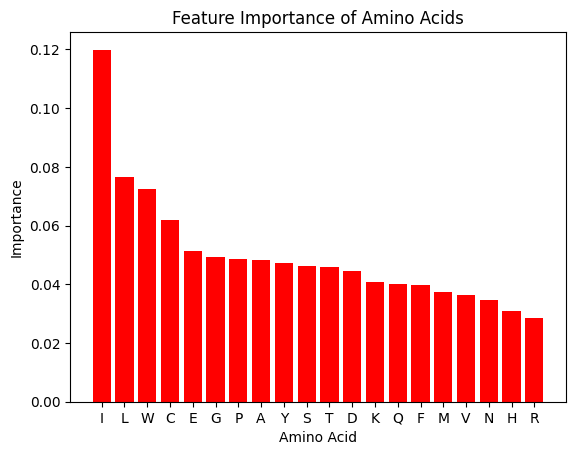

In [ ]:
# Feature importance visualization
best_model = grid.best_estimator_
importance = best_model.feature_importances_
df = pd.DataFrame({'Amino Acid': amino_acids, 'Importance': importance})
df = df.sort_values(by='Importance', ascending=False)
print(df)

plt.figure()
plt.bar(df["Amino Acid"], df["Importance"], color = 'red')
plt.xlabel("Amino Acid")
plt.ylabel("Importance")
plt.title("Feature Importance of Amino Acids")
plt.show()